# Sample Data

Sample path: Data/one/b9cccd01_nohash_0.wav
Sample Rate: 22050


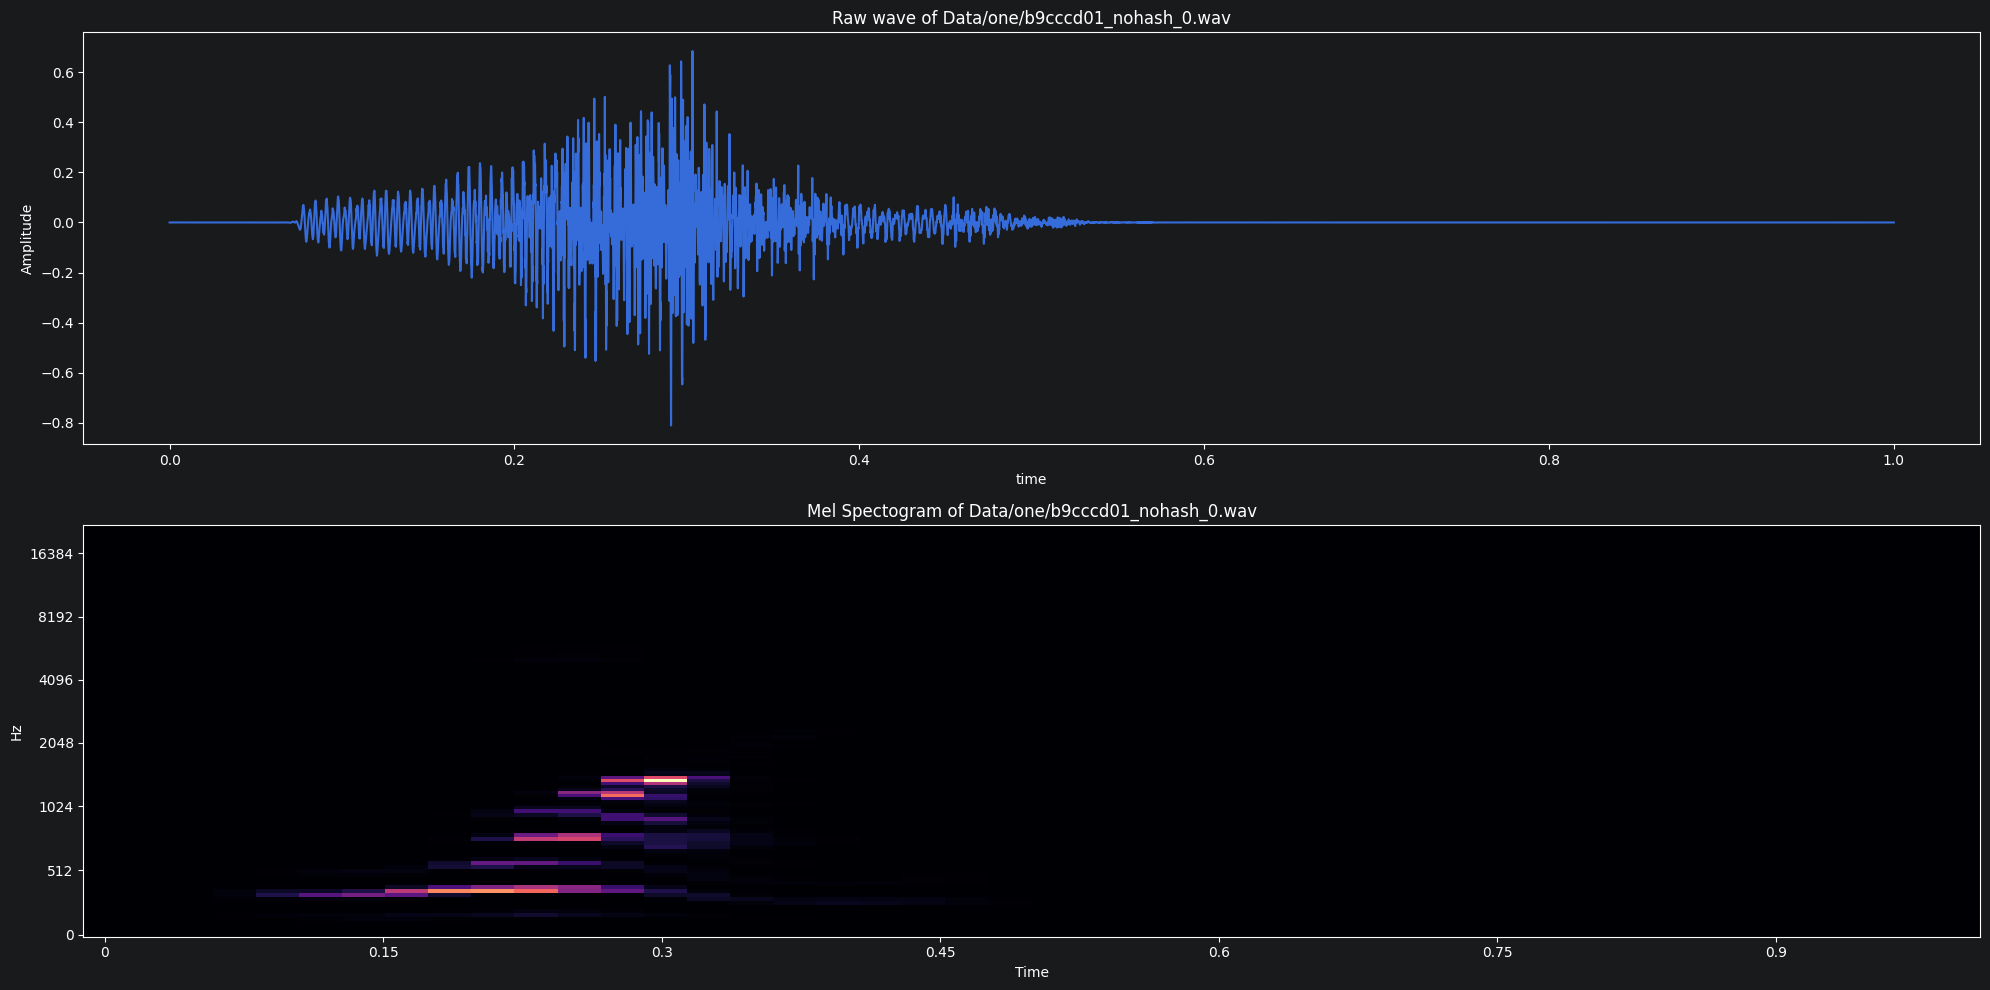

In [14]:
import os
import librosa
import matplotlib.pyplot as plt
import numpy as np
import torchaudio

PATH = os.path.join('Data', 'one')
files = os.listdir(PATH)
sample_path = os.path.join(PATH, files[0])

audio, sr = librosa.load(path = sample_path)
print(f'Sample path: {sample_path}\nSample Rate: {sr}')



fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20,10))

# Raw Wave
ax1.set_title(f'Raw wave of {sample_path}')
ax1.set_xlabel('time')
ax1.set_ylabel('Amplitude')
ax1.plot(np.linspace(0, sr/len(audio), sr), audio)


# Mel Spectrogram
spect = librosa.feature.melspectrogram(y=audio, sr=sr)
librosa.display.specshow(spect, x_axis='time', y_axis='mel', sr=sr, fmax=sr, ax=ax2)
ax2.set_title(f'Mel Spectrogram of {sample_path}')

plt.tight_layout()
plt.show()



In [16]:
from IPython.display import Audio

Audio(audio, rate=sr)

# Data Calculation

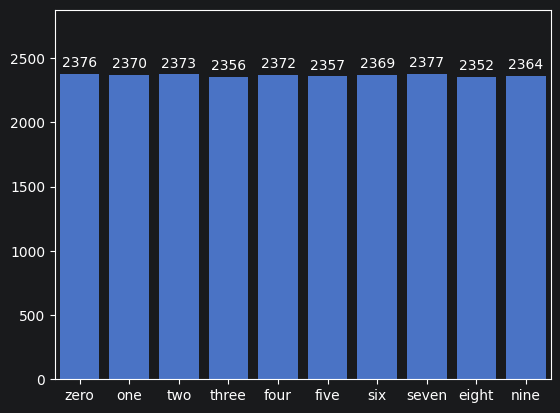

In [26]:
import seaborn as sns

CHOSEN_AUDIO = ['zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine']

count = {}
for name in CHOSEN_AUDIO:
    count[name] = len(os.listdir(os.path.join('Data', name)))

ax = plt.subplot()
sns.barplot(x=CHOSEN_AUDIO, y=count.values(), ax=ax)
ax.set_ylim(0, max(count.values()) + 500)
# Annotate using bar_label
for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=3)

ax.set_title("Amount of Samples for choosen words")


plt.show()

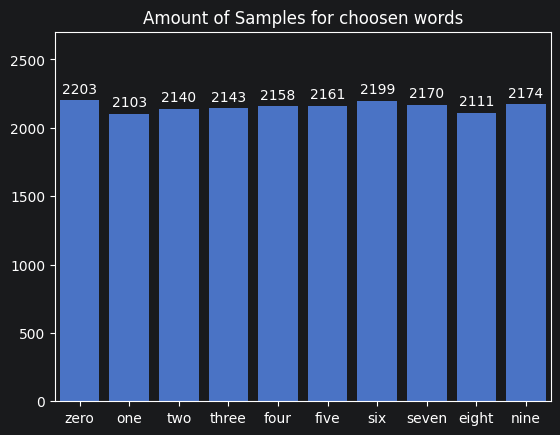

In [36]:
import soundfile as sf

DATASET_PATH = os.path.join('Data', 'Digits')
os.makedirs(DATASET_PATH, exist_ok=True)

CHOSEN_AUDIO = ['zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine']

count = {}
for name in CHOSEN_AUDIO:
    files = os.listdir(os.path.join('Data', name))
    target_samples = []

    for file in files:
        # Loading and Resampling
        sample, sr = librosa.load(os.path.join('Data', name, file))
        sample = librosa.resample(np.asarray(sample,dtype=np.float32), orig_sr=sr,target_sr=8000)

        # Checking Length
        if len(sample) == 8000:
            target_samples.append(sample)

            # Saving
            os.makedirs(os.path.join(DATASET_PATH, name), exist_ok=True)
            path = os.path.join(DATASET_PATH, name, file)
            sf.write(path, sample, 8000)

    #Count
    count[name] = len(target_samples)

ax = plt.subplot()
sns.barplot(x=CHOSEN_AUDIO, y=count.values(), ax=ax)
ax.set_ylim(0, max(count.values()) + 500)

# Annotate using bar_label
for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=3)

ax.set_title("Amount of Samples for choosen words")


plt.show()

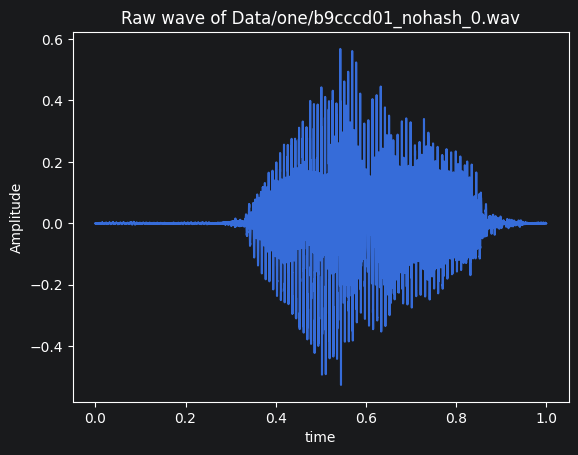

In [37]:
a, sr = librosa.load(os.path.join('Data', 'Digits', 'zero', '0b56bcfe_nohash_0.wav'), sr=8000)

ax1 = plt.subplot()
ax1.set_title(f'Raw wave of {sample_path}')
ax1.set_xlabel('time')
ax1.set_ylabel('Amplitude')
ax1.plot(np.linspace(0, sr/len(a), sr), a)



# Create Data Set
This funtions will be moved to utils for future usage

In [6]:
# TODO: implement data set with weighted sampling
import os
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchaudio
import torch

class AudioDataset(Dataset):
    def __init__(self, root_dir:str, classes: list[str] | None = None):
        if classes is None:
            classes = os.listdir(root_dir)

        self.class_to_idx = {name: idx for idx, name in enumerate(classes)}

        file_paths = []
        labels = []

        for c in classes:
            files = os.listdir(os.path.join(root_dir, c))
            for file in files:
                file_paths.append(os.path.join(root_dir, c, file))
                labels.append(self.class_to_idx[c])

        self.file_paths = file_paths
        self.labels = labels

    def __len__(self) -> int:
        return  len(self.file_paths)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, int]:
        data, sr = torchaudio.load(self.file_paths[idx])
        label = self.labels[idx]

        return data, label

def _get_weighted_sampler(dataset: AudioDataset) -> WeightedRandomSampler:
    labels = torch.tensor(dataset.labels)
    class_counts = torch.bincount(labels, minlength=len(dataset.class_to_idx))

    # Guard against empty classes
    if (class_counts == 0).any():
        empty = [k for k, v in dataset.class_to_idx.items() if class_counts[v] == 0]
        raise ValueError(f"Classes with no samples found: {empty}")

    class_weights = 1.0 / class_counts.float()
    sample_weights = class_weights[labels]

    return WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

def get_dataloader(dataset:AudioDataset, batch_size: int = 32, num_workers: int = 4,) -> DataLoader:
    sampler = _get_weighted_sampler(dataset)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        sampler=sampler,
        num_workers=num_workers,
        pin_memory=True,
    )


path = os.path.join('Data', 'Digits')
classes = ['zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine']
dataset = AudioDataset(path, classes)
loader = get_dataloader(dataset, batch_size=10)

# Test Batch
x,y = next(iter(loader))
print(x.shape, y)

torch.Size([10, 1, 8000]) tensor([6, 8, 3, 7, 0, 2, 0, 0, 0, 2])
